In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jaxopt
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import Delaunay
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tinygp import GaussianProcess, kernels, transforms
from tinygp.kernels.distance import L2Distance
from tqdm.auto import tqdm

/home/ssage/mambaforge/envs/hackathon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NUM_TRAIN_SAMPLES = 1000
NUM_TEST_SAMPLES = 200

ell = np.arange(2, 3001)
dl_to_cl_factor = ell * (ell + 1) / (2 * np.pi)

DATA_DIR = "./hackathon_cmb_emulator/data"


def load_spectra(data_dir, n):
    # cl_<i>.txt has TT, TE, EE columns; we only need TE.
    cls = np.zeros((n, len(ell)))
    for i in range(1, n + 1):
        cl_tt, cl_te, cl_ee = np.loadtxt(f"{data_dir}/cl_{i}.txt", unpack=True)  # noqa: RUF059
        cls[i - 1] = cl_te
    return cls


train_cosmologies = np.loadtxt(f"{DATA_DIR}/train_1000_wide/cosmologies.txt")
test_cosmologies = np.loadtxt(f"{DATA_DIR}/test_200/cosmologies.txt")
train_cls = load_spectra(f"{DATA_DIR}/train_1000_wide", NUM_TRAIN_SAMPLES)
test_cls = load_spectra(f"{DATA_DIR}/test_200", NUM_TEST_SAMPLES)

In [3]:
train_cls = train_cls / dl_to_cl_factor

cls_scaler = StandardScaler().fit(train_cls)
train_logcls = cls_scaler.transform(train_cls)

In [4]:
N_COMPONENTS = 45

pca = PCA(n_components=N_COMPONENTS, svd_solver="randomized", iterated_power=3, random_state=42)
train_pca_coeffs = pca.fit_transform(train_logcls)  # (n_samples, N_COMPONENTS)

print("train_pca_coeffs shape:", train_pca_coeffs.shape)
print("per-component std (what each GP has to fit):")
print(np.round(train_pca_coeffs.std(axis=0), 3))

train_pca_coeffs shape: (1000, 45)
per-component std (what each GP has to fit):
[3.9995e+01 2.4270e+01 1.9298e+01 1.2805e+01 9.9540e+00 8.0090e+00
 7.5870e+00 4.0670e+00 3.6050e+00 2.7900e+00 2.2210e+00 1.8840e+00
 1.4620e+00 1.1740e+00 1.0200e+00 8.3400e-01 7.5400e-01 7.0600e-01
 5.5900e-01 4.9000e-01 3.4800e-01 3.2000e-01 2.9900e-01 2.5900e-01
 2.5000e-01 1.9500e-01 1.6300e-01 1.3500e-01 1.2400e-01 1.0800e-01
 7.6000e-02 6.8000e-02 5.1000e-02 4.9000e-02 4.2000e-02 3.4000e-02
 3.1000e-02 2.7000e-02 2.5000e-02 1.9000e-02 1.8000e-02 1.6000e-02
 1.1000e-02 1.1000e-02 9.0000e-03]


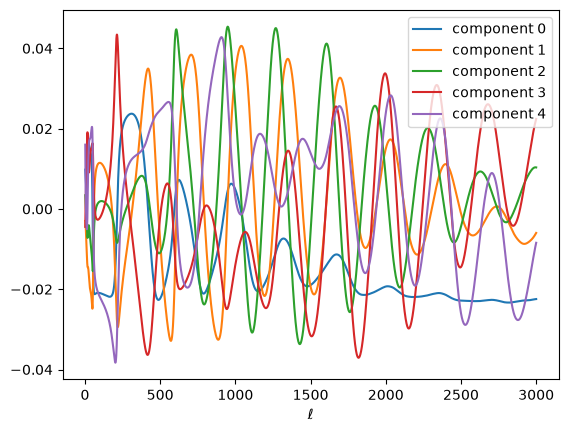

In [5]:
# Sanity check: what do the leading PCA modes look like?
for i in range(5):
    plt.plot(ell, pca.components_[i], label=f"component {i}")
plt.xlabel(r"$\ell$")
plt.legend()
plt.show()

In [6]:
coeff_scaler = StandardScaler().fit(train_pca_coeffs)
Y_train = coeff_scaler.transform(train_pca_coeffs)

cosmo_scaler = StandardScaler().fit(train_cosmologies)
X_train = jnp.asarray(cosmo_scaler.transform(train_cosmologies))

In [7]:
# --- How much of the test set is interpolation vs extrapolation? ---
# GPs are typically unreliable outside the region spanned by the training inputs, so before
# trusting test-set error metrics we should know how many test cosmologies actually fall
# outside the training footprint in parameter space, and by how much.

PARAM_LABELS = ["h", "omch2", "ombh2", "ln(10^10 As)", "ns", "tau"]

X_test = jnp.asarray(cosmo_scaler.transform(test_cosmologies))  # also reused later for GP predictions

# 1) Per-parameter bounding box: does each test cosmology fall within the observed 1D range
# of each training parameter? Necessary but not sufficient for "inside the training set" --
# it's the loosest possible check, a strict superset of the true convex hull.
train_min = train_cosmologies.min(axis=0)
train_max = train_cosmologies.max(axis=0)
outside_bbox_per_dim = (test_cosmologies < train_min) | (test_cosmologies > train_max)
outside_bbox = outside_bbox_per_dim.any(axis=1)

# 2) Convex hull in the same standardized 6D space the GP kernel actually operates in. This
# is the correct notion of "interpolation region": a point can pass the per-parameter bbox
# check on every axis individually and still sit outside the hull, e.g. near a corner that
# the finite Sobol/LHS training sample didn't fill. In 6D the hull volume can be dramatically
# smaller than the bounding box volume, so this is worth checking explicitly rather than
# assuming the bbox check is representative.
hull = Delaunay(np.asarray(X_train), qhull_options="QJ")  # QJ: joggle inputs, avoids precision failures
inside_hull = hull.find_simplex(np.asarray(X_test)) >= 0
outside_hull = ~inside_hull

# 3) Distance to the nearest training point in standardized space, as a continuous severity
# measure -- two points can both be "outside the hull" while one is a hair's breadth past the
# boundary and the other is far past every training sample.
nn_dist_test = np.min(
    np.linalg.norm(np.asarray(X_test)[:, None, :] - np.asarray(X_train)[None, :, :], axis=-1), axis=1
)

print(f"{outside_bbox.sum():3d} / {NUM_TEST_SAMPLES} test samples ({100 * outside_bbox.mean():.1f}%) "
      f"fall outside the training bounding box (loose check)")
print(f"{outside_hull.sum():3d} / {NUM_TEST_SAMPLES} test samples ({100 * outside_hull.mean():.1f}%) "
      f"fall outside the training convex hull (true extrapolation)")
print()
print("extrapolation rate by parameter (bounding-box sense):")
for k, name in enumerate(PARAM_LABELS):
    print(f"  {name:14s} {100 * outside_bbox_per_dim[:, k].mean():5.1f}%")

  0 / 200 test samples (0.0%) fall outside the training bounding box (loose check)
 37 / 200 test samples (18.5%) fall outside the training convex hull (true extrapolation)

extrapolation rate by parameter (bounding-box sense):
  h                0.0%
  omch2            0.0%
  ombh2            0.0%
  ln(10^10 As)     0.0%
  ns               0.0%
  tau              0.0%


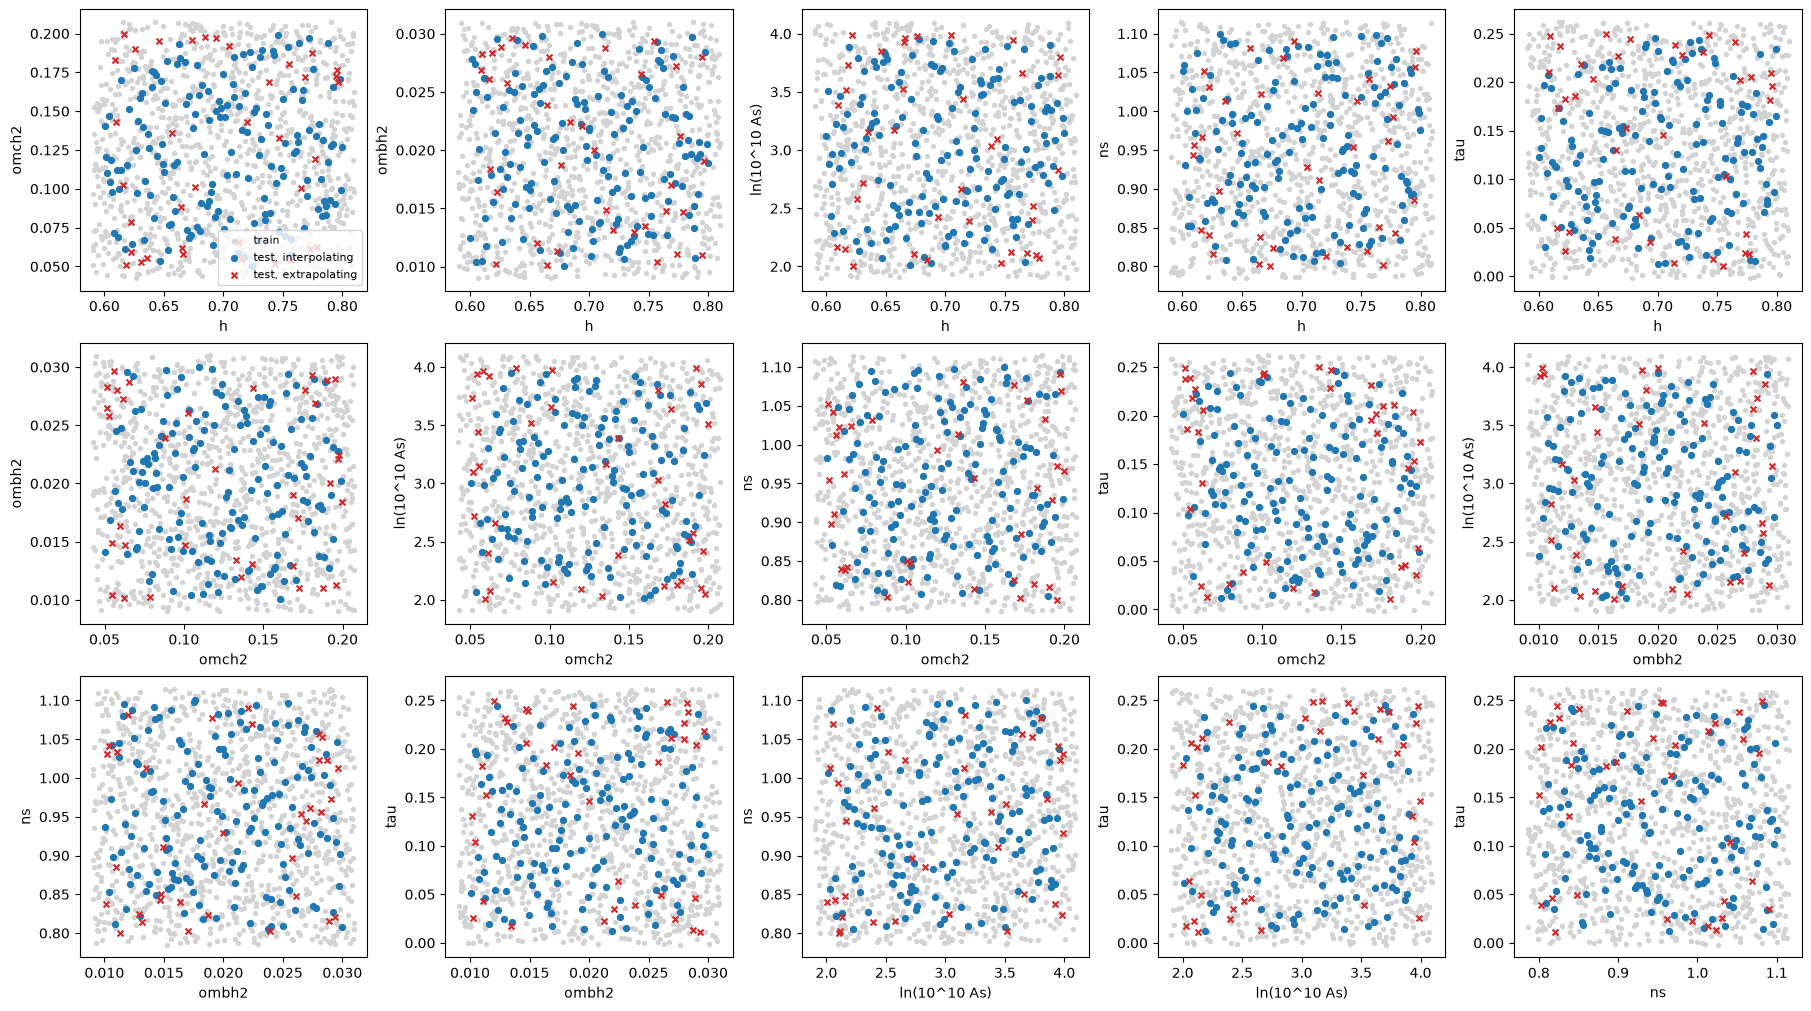

In [8]:
# Visualize which corners of parameter space the extrapolating test points sit in.
from itertools import combinations

fig, axes = plt.subplots(3, 5, figsize=(18, 10), constrained_layout=True)
for ax, (i, j) in zip(axes.ravel(), combinations(range(len(PARAM_LABELS)), 2)):
    ax.scatter(train_cosmologies[:, i], train_cosmologies[:, j], s=8, c="lightgray", label="train")
    ax.scatter(test_cosmologies[inside_hull, i], test_cosmologies[inside_hull, j],
               s=18, c="tab:blue", label="test, interpolating")
    ax.scatter(test_cosmologies[outside_hull, i], test_cosmologies[outside_hull, j],
               s=18, c="tab:red", marker="x", label="test, extrapolating")
    ax.set_xlabel(PARAM_LABELS[i])
    ax.set_ylabel(PARAM_LABELS[j])
axes.ravel()[0].legend(fontsize=8, loc="best")
plt.show()

In [9]:
N_IN = train_cosmologies.shape[1]
N_RESTARTS = 2

# L2Distance makes this match sklearn's Matern (tinygp's default is L1/Manhattan, a different kernel).
KERNEL_FAMILY = lambda: kernels.Matern52(distance=L2Distance())

DIAG = 1e-6  # fixed numerical jitter, not fitted


def build_gp(theta, X_):
    amp = jnp.exp(theta["log_amp"])
    lengthscale = jnp.exp(theta["log_ell"])  # one per input dimension
    kernel = amp**2 * transforms.Linear(1.0 / lengthscale, KERNEL_FAMILY())  # amp**2 = kernel variance
    return GaussianProcess(kernel, X_, diag=DIAG)


def neg_log_prob(theta, X_, y_):
    return -build_gp(theta, X_).log_probability(y_)

In [10]:
# scipy's compiled L-BFGS-B (via jaxopt), matching sklearn's GP optimizer. Can't run
# inside jit/pmap since it shells out to scipy, so components are fit one at a time below.
ELL_BOUNDS = (1e-2, 1e3)
VARIANCE_BOUNDS = (1e-3, 1e3)  # = amp**2 bounds
LOWER = {"log_amp": 0.5 * np.log(VARIANCE_BOUNDS[0]), "log_ell": jnp.full(N_IN, np.log(ELL_BOUNDS[0]))}
UPPER = {"log_amp": 0.5 * np.log(VARIANCE_BOUNDS[1]), "log_ell": jnp.full(N_IN, np.log(ELL_BOUNDS[1]))}
scipy_solver = jaxopt.ScipyBoundedMinimize(fun=neg_log_prob, method="L-BFGS-B")


def fit_one_output(X_, y_, n_restarts=N_RESTARTS, seed=0):
    """Fit one GP with multi-start restarts (the likelihood isn't convex).
    Restarts are seeded from a narrow window -- a wide random draw can send several
    lengthscales to their bound at once, which collapses the kernel to near rank-1 and
    blows up the likelihood. The optimizer can still reach the full wide bounds from a
    narrow start when the data supports it.
    Returns every restart's final NLL too, to check if restarts land on different minima."""
    rng_r = np.random.default_rng(seed)
    best = None
    restart_vals = []
    for _ in range(n_restarts):
        theta0 = {
            "log_amp": jnp.asarray(rng_r.uniform(-1, 1)),
            "log_ell": jnp.asarray(rng_r.uniform(-1, 1, N_IN)),
        }
        soln = scipy_solver.run(theta0, bounds=(LOWER, UPPER), X_=X_, y_=y_)
        restart_vals.append(float(soln.state.fun_val))
        if best is None or soln.state.fun_val < best.state.fun_val:
            best = soln
    return best.params, np.array(restart_vals)

In [11]:
all_restart_vals = []
fitted_params = []
for k in tqdm(range(N_COMPONENTS), desc="fitting GPs"):
    params, restart_vals = fit_one_output(X_train, Y_train[:, k], seed=k)
    all_restart_vals.append(restart_vals)
    fitted_params.append(params)

fitting GPs: 100%|██████████| 45/45 [07:51<00:00, 10.48s/it]


In [12]:
for k, params in enumerate(fitted_params):
    amp = float(jnp.exp(params["log_amp"]))
    lengthscale = np.exp(np.asarray(params["log_ell"]))
    restart_nlls = all_restart_vals[k]
    spread = restart_nlls.max() - restart_nlls.min()
    print(f"component {k:2d}: amp={amp:8.4f}  ell={np.round(lengthscale, 3)}  "
          f"restart_nlls={np.round(restart_nlls, 4)}  spread={spread:.4f}")

component  0: amp= 31.6228  ell=[ 63.707  14.718  24.91   19.593 105.559  68.386]  restart_nlls=[-2827.9167 -2827.9167]  spread=0.0000
component  1: amp= 25.8339  ell=[ 21.558   4.487  26.248  20.721 103.037  49.762]  restart_nlls=[-1846.0914 -1846.0914]  spread=0.0000
component  2: amp= 31.6228  ell=[17.728  3.838 22.52  19.837 92.492 58.171]  restart_nlls=[-1387.2312 -1387.2312]  spread=0.0000
component  3: amp= 28.6750  ell=[12.797  2.854 16.976 18.402 63.432 48.642]  restart_nlls=[-871.3452 -871.3452]  spread=0.0000
component  4: amp= 30.8302  ell=[13.593  3.034 16.354 19.441 56.436 47.812]  restart_nlls=[-848.3605 -848.3605]  spread=0.0000
component  5: amp= 31.6228  ell=[11.593  2.657 13.736 16.316 46.046 49.316]  restart_nlls=[-473.9107 1418.9385]  spread=1892.8492
component  6: amp= 31.6228  ell=[15.626  3.809 14.708 16.632 32.228 41.424]  restart_nlls=[-745.2604 -745.2604]  spread=0.0000
component  7: amp= 31.6228  ell=[10.     2.254 11.945 15.978 33.689 46.114]  restart_nlls=

In [13]:
# TE's cosmic variance depends on Cl_TT and Cl_EE too (see build_gp cells above for why
# dividing by Cl_TE itself breaks down at its zero crossings), so load those for the test
# cosmologies as well -- only needed here, not for training the TE emulator itself.
def load_tt_ee(data_dir, n):
    tt = np.zeros((n, len(ell)))
    ee = np.zeros((n, len(ell)))
    for i in range(1, n + 1):
        cl_tt, cl_te, cl_ee = np.loadtxt(f"{data_dir}/cl_{i}.txt", unpack=True)  # noqa: RUF059
        tt[i - 1] = cl_tt
        ee[i - 1] = cl_ee
    return tt, ee


test_cls_tt, test_cls_ee = load_tt_ee(f"{DATA_DIR}/test_200", NUM_TEST_SAMPLES)

In [14]:
# Predict each PCA coefficient for the test cosmologies, then invert
# PCA -> component scaling -> log(Cl) scaling -> Cl to get predicted spectra.
X_test = jnp.asarray(cosmo_scaler.transform(test_cosmologies))

pred_coeffs_scaled = jnp.stack(
    [build_gp(params, X_train).predict(Y_train[:, k], X_test) for k, params in enumerate(fitted_params)],
    axis=1,
)  # (NUM_TEST_SAMPLES, N_COMPONENTS)

pred_coeffs = coeff_scaler.inverse_transform(np.asarray(pred_coeffs_scaled))
pred_logcls_scaled = pca.inverse_transform(pred_coeffs)
pred_logcls = cls_scaler.inverse_transform(pred_logcls_scaled)
pred_cls = pred_logcls * dl_to_cl_factor

# Full-sky, noise-free cosmic variance for a cross-spectrum (Knox 1995):
# sigma(ell) = sqrt((Cl_TT*Cl_EE + Cl_TE**2) / (2*ell+1)). This stays well-behaved through
# TE's zero crossings, unlike dividing by Cl_TE itself.
cosmic_variance = np.sqrt((test_cls_tt * test_cls_ee + test_cls**2) / (2 * ell + 1))
err_sigma = (pred_cls - test_cls) / cosmic_variance

print("mean |error| in cosmic-variance sigma per spectrum:", np.mean(np.abs(err_sigma), axis=1).mean())
print("median |error| in cosmic-variance sigma per spectrum:", np.median(np.mean(np.abs(err_sigma), axis=1)))
print("worst-case |error| in cosmic-variance sigma:", np.abs(err_sigma).max())

mean |error| in cosmic-variance sigma per spectrum: 0.22997944872735102
median |error| in cosmic-variance sigma per spectrum: 0.18031495534030612
worst-case |error| in cosmic-variance sigma: 7.475368919611509


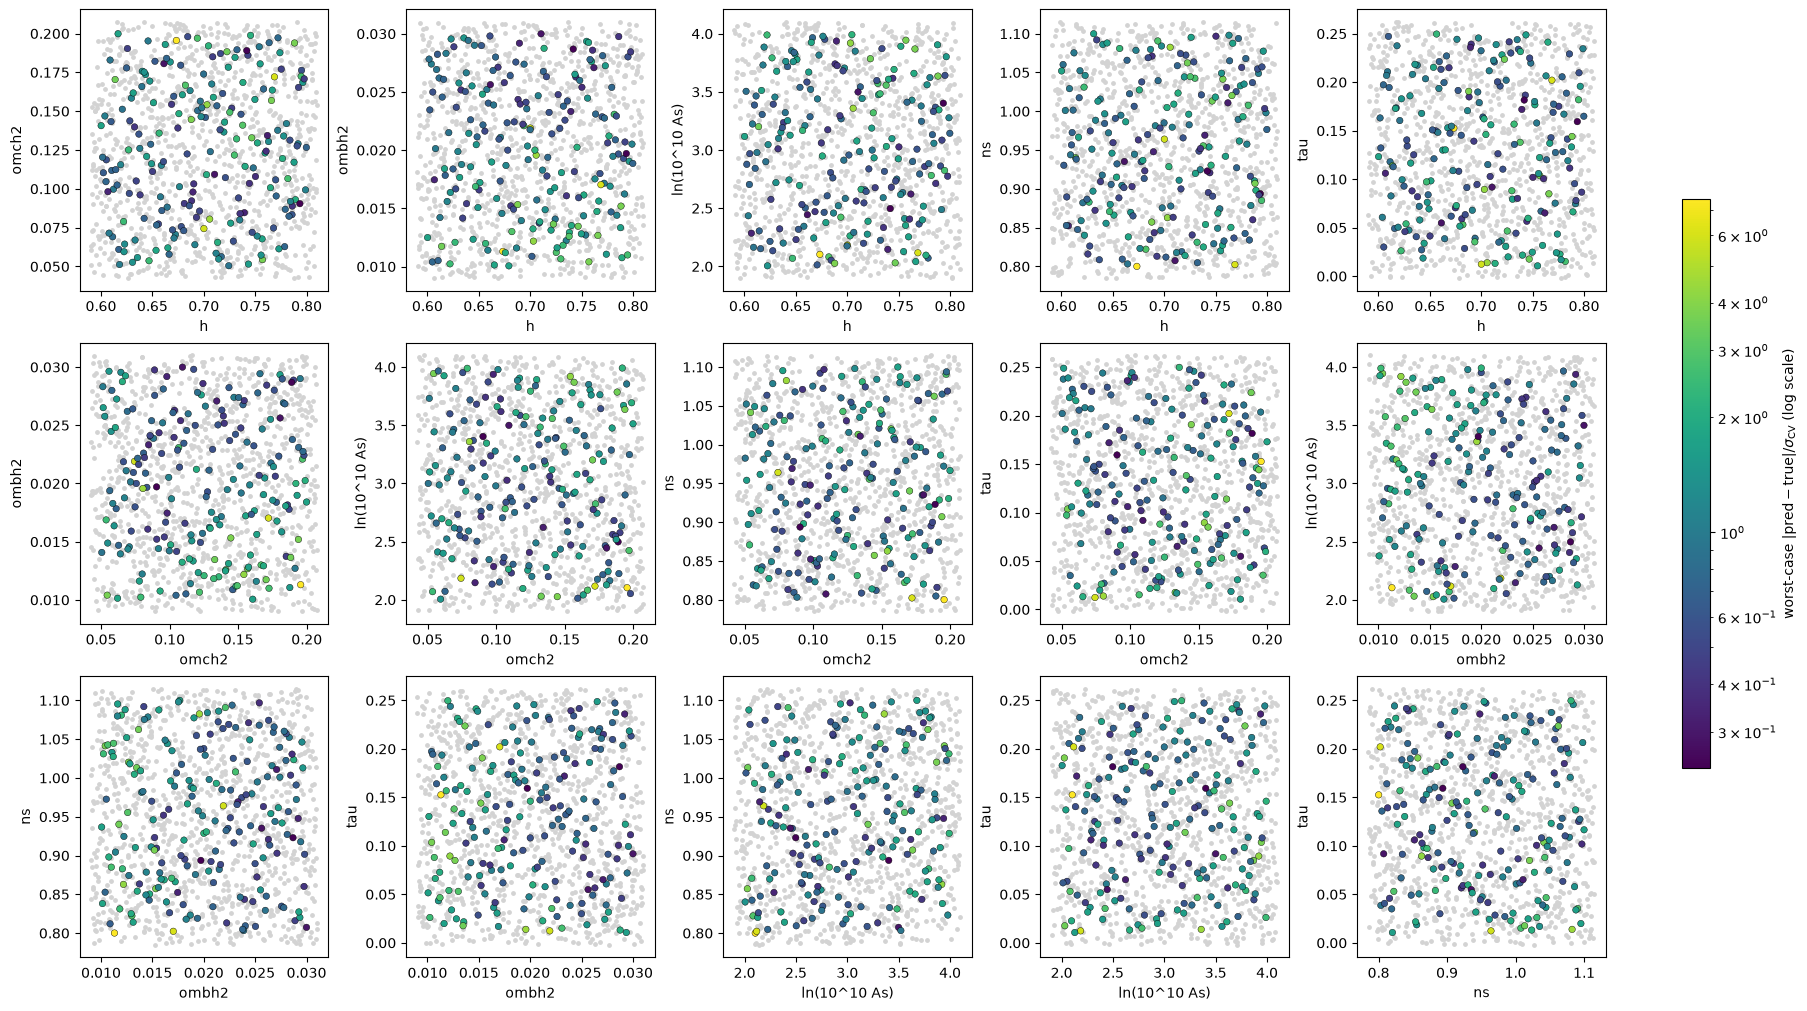

In [15]:
# Pairwise (x1, x2) view of every test cosmology, colored by its worst-case error anywhere in
# ell (a stronger stress test than the mean per spectrum). If bad samples cluster at the edges
# of the training footprint, that's extrapolation; if they're scattered in the interior instead,
# something else is going on (e.g. a parameter degeneracy the GP kernel can't resolve).
worst_case_err = np.max(np.abs(err_sigma), axis=1)  # per test cosmology, worst ell

norm = plt.matplotlib.colors.LogNorm(vmin=worst_case_err[worst_case_err > 0].min(), vmax=worst_case_err.max())
fig, axes = plt.subplots(3, 5, figsize=(18, 10), constrained_layout=True)
for ax, (i, j) in zip(axes.ravel(), combinations(range(len(PARAM_LABELS)), 2)):
    ax.scatter(train_cosmologies[:, i], train_cosmologies[:, j], s=6, c="lightgray", zorder=1, label="train")
    sc = ax.scatter(test_cosmologies[:, i], test_cosmologies[:, j], c=worst_case_err, cmap="viridis",
                     norm=norm, s=22, zorder=2, edgecolors="black", linewidths=0.3)
    ax.set_xlabel(PARAM_LABELS[i])
    ax.set_ylabel(PARAM_LABELS[j])
fig.colorbar(sc, ax=axes, shrink=0.6, label=r"worst-case $|{\rm pred}-{\rm true}|/\sigma_{\rm CV}$ (log scale)")
plt.show()

mean per-spectrum error, interpolating test points: 0.2003
mean per-spectrum error, extrapolating test points: 0.3609


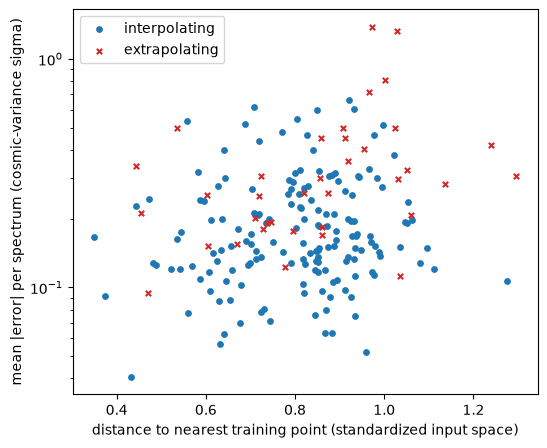

In [16]:
# Does "outside the training convex hull" actually predict worse emulator error? Ties the
# interpolation/extrapolation split computed earlier (inside_hull, outside_hull, nn_dist_test)
# back to the real prediction error on this test set.
per_spectrum_err = np.mean(np.abs(err_sigma), axis=1)  # mean |error| in cosmic-variance sigma, per test cosmology

print(f"mean per-spectrum error, interpolating test points: {per_spectrum_err[inside_hull].mean():.4f}")
print(f"mean per-spectrum error, extrapolating test points: {per_spectrum_err[outside_hull].mean():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(nn_dist_test[inside_hull], per_spectrum_err[inside_hull], s=15, c="tab:blue", label="interpolating")
ax.scatter(nn_dist_test[outside_hull], per_spectrum_err[outside_hull], s=15, c="tab:red", marker="x", label="extrapolating")
ax.set_xlabel("distance to nearest training point (standardized input space)")
ax.set_ylabel("mean |error| per spectrum (cosmic-variance sigma)")
ax.set_yscale("log")
ax.legend()
plt.show()

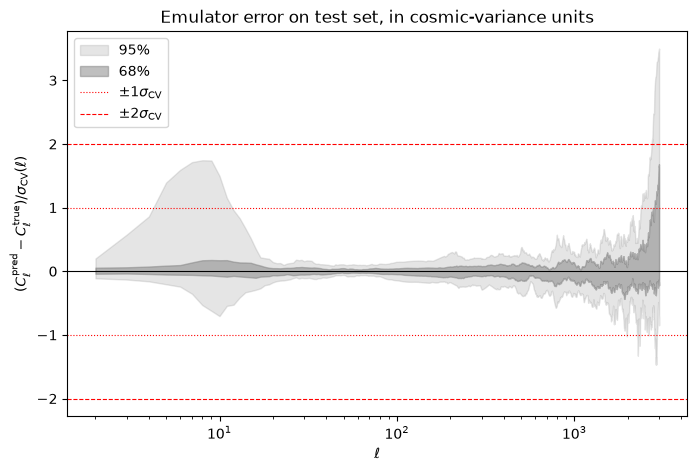

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

lo95, hi95 = np.percentile(err_sigma, [2.5, 97.5], axis=0)
lo68, hi68 = np.percentile(err_sigma, [16, 84], axis=0)
ax.fill_between(ell, lo95, hi95, alpha=0.2, color="gray", label="95%")
ax.fill_between(ell, lo68, hi68, alpha=0.5, color="gray", label="68%")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="red", lw=0.8, ls=":", label=r"$\pm 1\sigma_{\rm CV}$")
ax.axhline(-1, color="red", lw=0.8, ls=":")
ax.axhline(2, color="red", lw=0.8, ls="--", label=r"$\pm 2\sigma_{\rm CV}$")
ax.axhline(-2, color="red", lw=0.8, ls="--")

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$(C_\ell^{\rm pred} - C_\ell^{\rm true}) / \sigma_{\rm CV}(\ell)$")
ax.set_title("Emulator error on test set, in cosmic-variance units")
ax.legend()
plt.show()

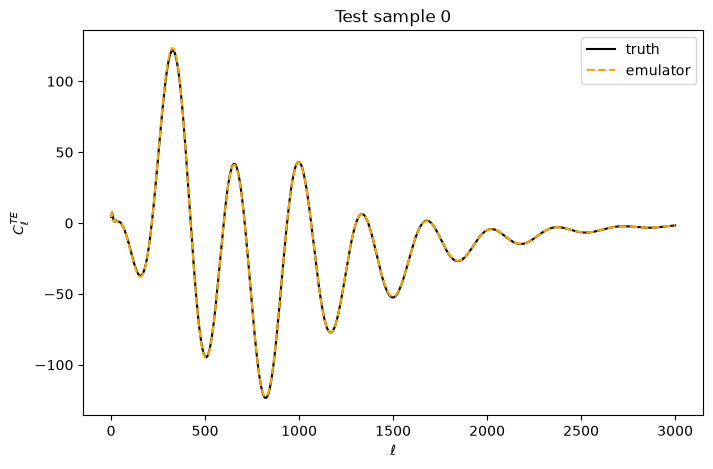

In [18]:
i = 0
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell, test_cls[i], color="black", label="truth")
ax.plot(ell, pred_cls[i], color="orange", ls="--", label="emulator")

#ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^{TE}$")
ax.set_title(f"Test sample {i}")
ax.legend()
plt.show()